# Student Academic Performance Prediction

## Use Case
Predict a student's **final mathematics grade (G3, scale 0–20)** based on 30 demographic, social, and academic features.  
Early identification of at-risk students allows schools to intervene before final exams.

## Dataset
**Name:** UCI Student Performance Dataset (`student-mat.csv`)  
**Source:** https://archive.ics.uci.edu/ml/datasets/Student+Performance  
**Citation:** P. Cortez and A. Silva. *Using Data Mining to Predict Secondary School Student Performance.* 2008.  
**Volume:** 395 students × 33 features  
**Variety:** Mix of numeric (age, grades, absences), ordinal (study time 1–4, alcohol 1–5), and categorical (school, sex, address, job, guardian) — 17 categorical + 16 numeric columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Download dataset programmatically
import urllib.request
import zipfile, os

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
if not os.path.exists('student-mat.csv'):
    urllib.request.urlretrieve(url, 'student.zip')
    with zipfile.ZipFile('student.zip', 'r') as z:
        z.extractall('.')
    print('Dataset downloaded.')

df = pd.read_csv('student-mat.csv', sep=';')
print(df.shape)
df.head()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Exploratory Data Analysis & Visualizations

In [2]:
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nNumeric columns ({len(df.select_dtypes(include=np.number).columns)}):',
      df.select_dtypes(include=np.number).columns.tolist())
print(f'\nCategorical columns ({len(df.select_dtypes(include=object).columns)}):',
      df.select_dtypes(include=object).columns.tolist())
df.describe()

Shape: (395, 33)
Missing values: 0

Numeric columns (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Visualization 1 — Target & Key Feature Distributions (Histograms)
Understanding the distribution of G3 and the most influential numeric features tells us:
- Whether the target is skewed (affects model choice and loss interpretation)
- Whether features need transformation before training

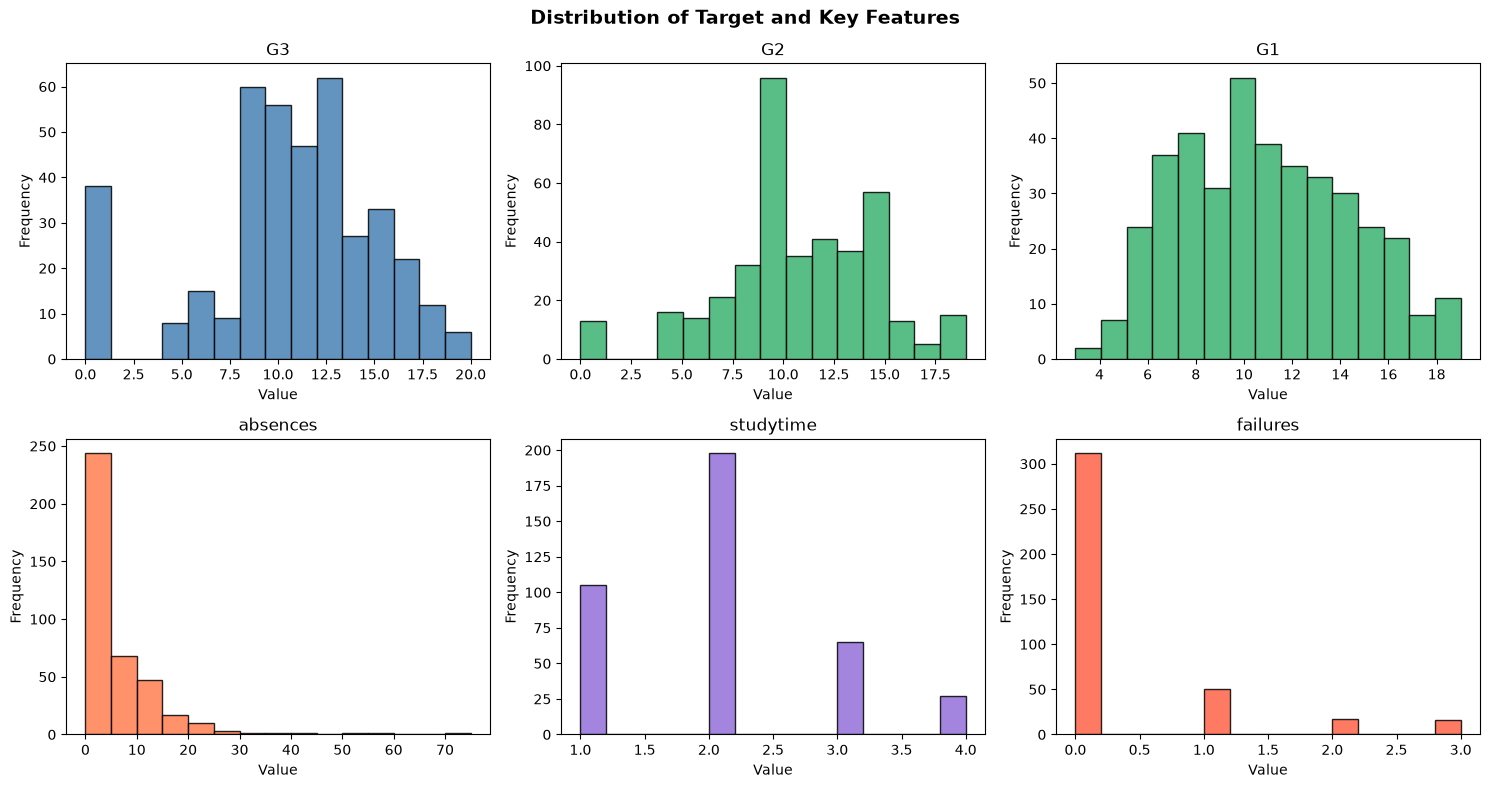

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Target and Key Features', fontsize=14, fontweight='bold')

plot_cols = ['G3', 'G2', 'G1', 'absences', 'studytime', 'failures']
colors    = ['steelblue', 'mediumseagreen', 'mediumseagreen', 'coral', 'mediumpurple', 'tomato']

for ax, col, color in zip(axes.flat, plot_cols, colors):
    ax.hist(df[col], bins=15, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('viz1_distributions.png', dpi=100)
plt.show()

**Interpretation:**
- **G3 (target):** Roughly bell-shaped but with a notable spike at 0 — students who scored zero (dropped out or failed entirely). This skew means MSE will be sensitive to those outliers.
- **G1 & G2:** Very similar distributions to G3, confirming they are the strongest predictors — students who performed well in period 1 and 2 almost always finish well.
- **absences:** Heavily right-skewed — most students miss very few classes, but a long tail of high absentees exists. This feature will be kept but its skew may reduce linear model accuracy.
- **studytime:** Ordinal 1–4, most students study 1–2 hours/week. Low study time is the norm, so this feature has limited variance.
- **failures:** Most students have 0 past failures. The rare students with 3–4 failures are likely the G3=0 outliers seen above — this feature is critical to keep.

### Visualization 2 — Correlation Heatmap
The heatmap reveals linear relationships between all numeric features and the target G3, directly guiding which features to keep, drop, or engineer.

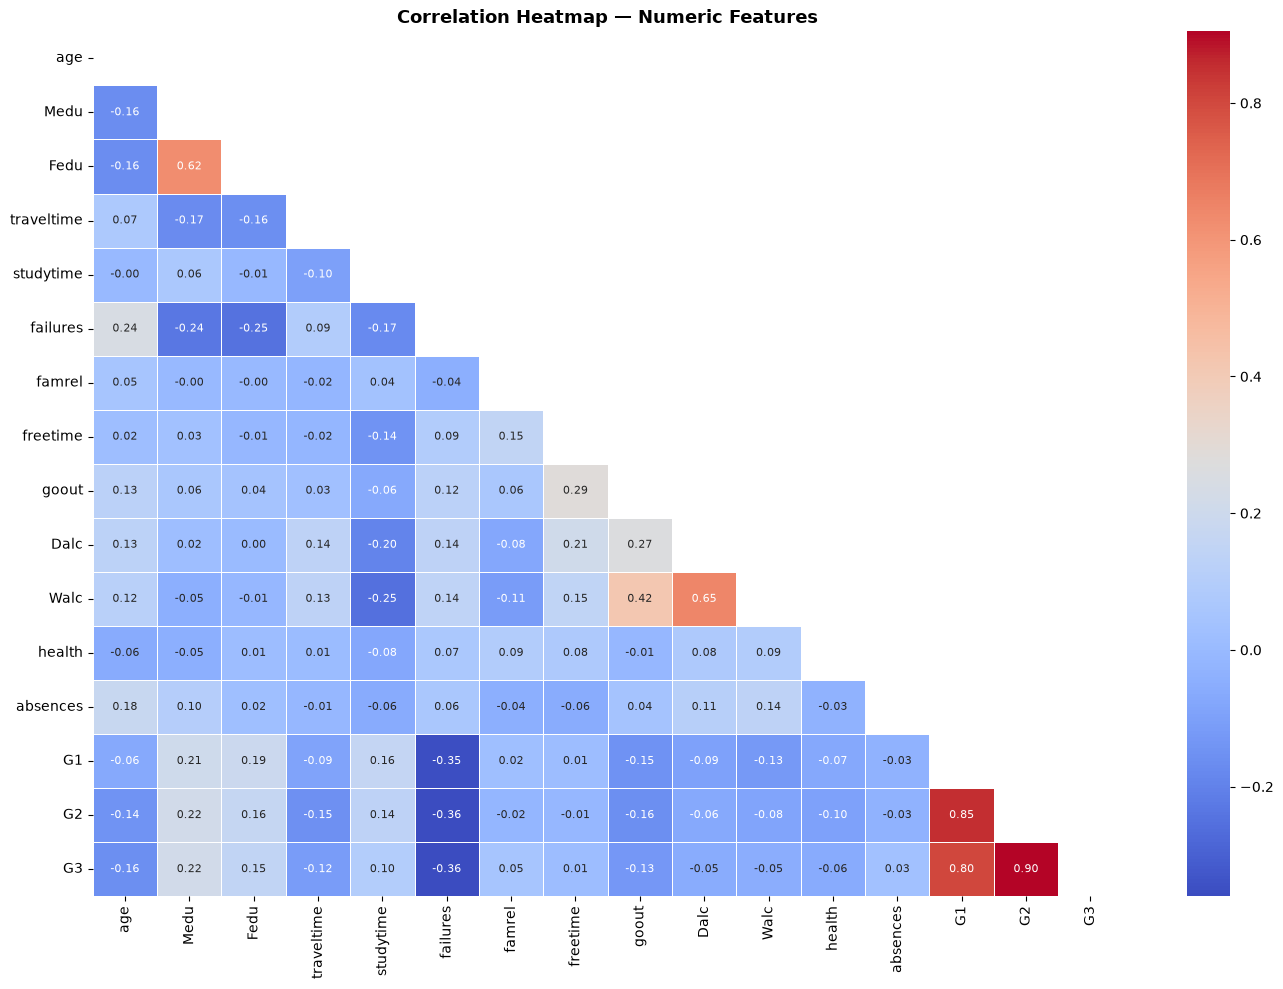

Top correlations with G3:
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415


In [4]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_heatmap.png', dpi=100)
plt.show()

# Print top correlations with G3
print('Top correlations with G3:')
print(corr['G3'].drop('G3').sort_values(ascending=False).to_string())

**Interpretation:**
- **G2 (r≈0.90) and G1 (r≈0.80):** Strongest predictors — prior performance is the best indicator of final grade. Both are kept.
- **failures (r≈-0.36):** Moderate negative correlation — students with past failures score lower. Kept.
- **Dalc/Walc (r≈-0.22/-0.20):** Alcohol consumption negatively impacts grades. Kept.
- **absences (r≈-0.09):** Weak negative correlation — kept but expected low weight in the model.
- **Medu/Fedu (r≈0.22/0.15):** Parental education has a mild positive effect. Kept.
- **age (r≈-0.16):** Older students slightly underperform — possibly due to grade repetition. Kept.

**Feature drop decisions based on heatmap:**
- `school`: Binary flag with near-zero correlation to G3 — dropped.
- `reason`: Categorical reason for school choice — subjective and uncorrelated — dropped.

### Visualization 3 — Scatter Plots: Key Features vs G3
Scatter plots reveal the nature of the relationship (linear vs non-linear) between top features and the target.

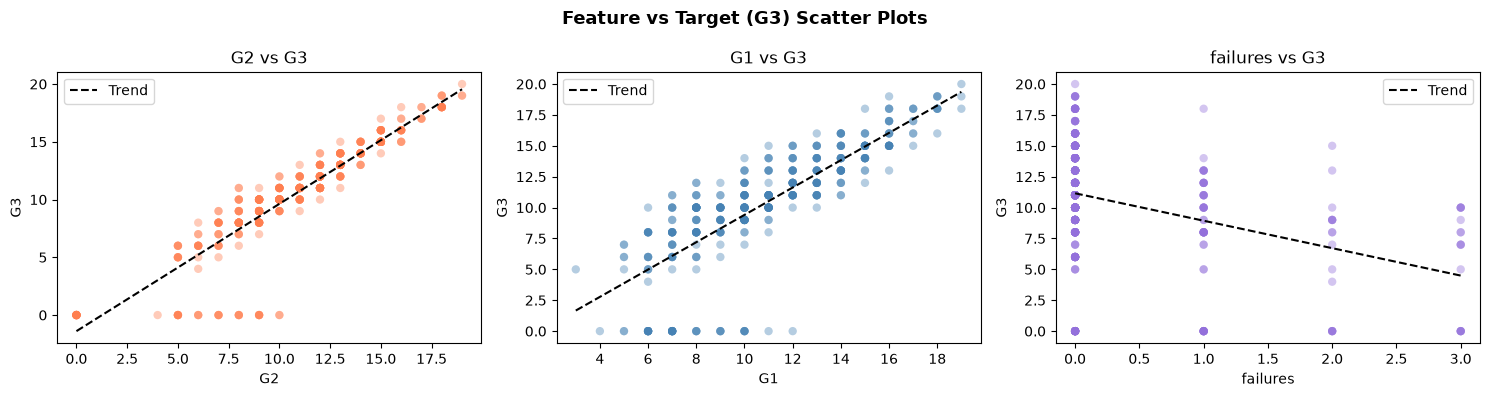

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature vs Target (G3) Scatter Plots', fontsize=13, fontweight='bold')

scatter_pairs = [('G2', 'coral'), ('G1', 'steelblue'), ('failures', 'mediumpurple')]

for ax, (col, color) in zip(axes, scatter_pairs):
    ax.scatter(df[col], df['G3'], alpha=0.4, color=color, edgecolors='none')
    m = np.polyfit(df[col], df['G3'], 1)
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, np.polyval(m, x_range), 'k--', linewidth=1.5, label='Trend')
    ax.set_xlabel(col)
    ax.set_ylabel('G3')
    ax.set_title(f'{col} vs G3')
    ax.legend()

plt.tight_layout()
plt.savefig('viz3_scatterplots.png', dpi=100)
plt.show()

**Interpretation:**
- **G2 vs G3:** Strong positive linear relationship — the trend line fits tightly, confirming G2 is the single most predictive feature. Linear regression is well-suited here.
- **G1 vs G3:** Similar strong linear trend, slightly more spread than G2 (G2 is closer in time to G3).
- **failures vs G3:** Clear negative trend — each additional past failure drops the expected G3 significantly. The cluster at failures=0 with wide G3 spread shows failures alone cannot explain all variance, justifying a multivariate model.

## Feature Engineering

In [6]:
# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# Drop columns with low predictive value based on correlation analysis
# 'G1' and 'G2' are intermediate grades — keep them as strong predictors
# Drop: 'school' (binary, low variance impact), 'reason' (subjective)
cols_to_drop = ['school', 'reason']
df_enc.drop(columns=cols_to_drop, inplace=True)
print('Dropped columns:', cols_to_drop)
print('Remaining features:', df_enc.shape[1])

Categorical columns to encode: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Dropped columns: ['school', 'reason']
Remaining features: 31


In [7]:
# Feature / Target split
X = df_enc.drop(columns=['G3'])
y = df_enc['G3']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train size:', X_train_sc.shape, '| Test size:', X_test_sc.shape)

Train size: (316, 30) | Test size: (79, 30)


## Model Training & Comparison

In [8]:
results = {}

# 1. Ordinary Least Squares Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
results['LinearRegression'] = {
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'R2':  r2_score(y_test, y_pred_lr),
    'model': lr
}

# 2. SGD Regressor (Stochastic Gradient Descent / Stochastic Linear Regression)
sgd = SGDRegressor(max_iter=1000, tol=1e-4, random_state=42, learning_rate='adaptive', eta0=0.01)
sgd.fit(X_train_sc, y_train)
y_pred_sgd = sgd.predict(X_test_sc)
results['SGDRegressor'] = {
    'MSE': mean_squared_error(y_test, y_pred_sgd),
    'R2':  r2_score(y_test, y_pred_sgd),
    'model': sgd
}

# 3. Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
results['DecisionTree'] = {
    'MSE': mean_squared_error(y_test, y_pred_dt),
    'R2':  r2_score(y_test, y_pred_dt),
    'model': dt
}

# 4. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
results['RandomForest'] = {
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'R2':  r2_score(y_test, y_pred_rf),
    'model': rf
}

# Print comparison
print(f"{'Model':<25} {'MSE':>10} {'R2':>10}")
print('-' * 47)
for name, v in results.items():
    print(f"{name:<25} {v['MSE']:>10.4f} {v['R2']:>10.4f}")

Model                            MSE         R2
-----------------------------------------------
LinearRegression              5.0263     0.7549
SGDRegressor                  5.0184     0.7553
DecisionTree                  5.0839     0.7521
RandomForest                  3.3725     0.8355


## Gradient Descent Loss Curve (SGD Regressor)

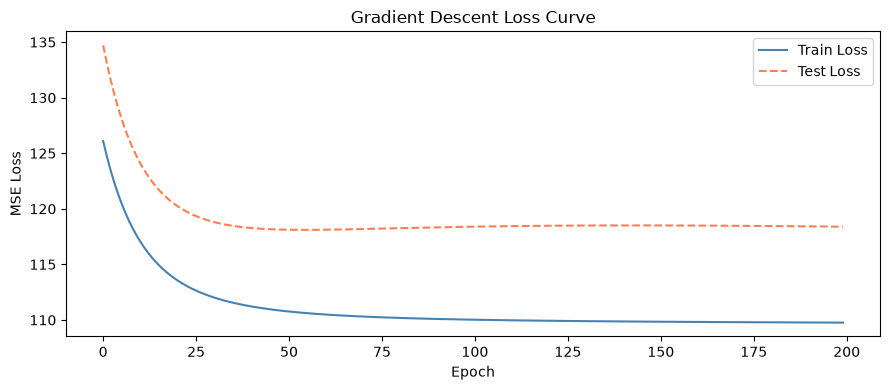

In [9]:
# Manual gradient descent to plot loss curve
def gradient_descent(X_tr, y_tr, X_te, y_te, lr=0.01, epochs=200):
    m, n = X_tr.shape
    theta = np.zeros(n)
    train_losses, test_losses = [], []
    for _ in range(epochs):
        pred_tr = X_tr @ theta
        grad = (2/m) * X_tr.T @ (pred_tr - y_tr)
        theta -= lr * grad
        train_losses.append(mean_squared_error(y_tr, X_tr @ theta))
        test_losses.append(mean_squared_error(y_te, X_te @ theta))
    return theta, train_losses, test_losses

theta, train_losses, test_losses = gradient_descent(
    X_train_sc, y_train.values, X_test_sc, y_test.values
)

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(test_losses,  label='Test Loss',  color='coral', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('viz3_loss_curve.png', dpi=100)
plt.show()

## Scatter Plot: Before & After (Best Fit Line)

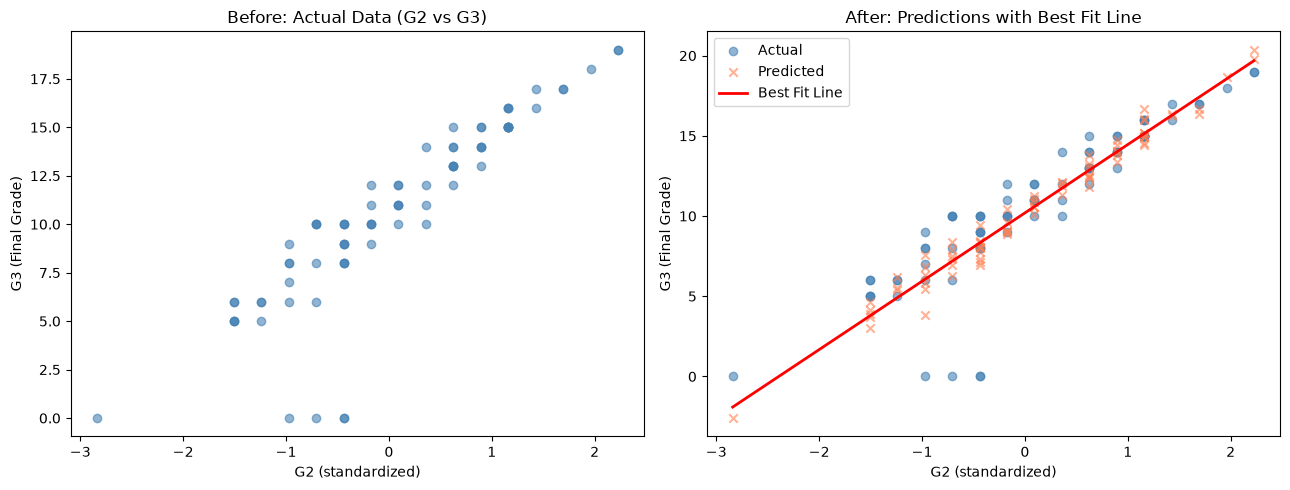

In [10]:
# Use G2 (most correlated single feature) for 2D scatter
g2_idx = list(X.columns).index('G2')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before: raw scatter
axes[0].scatter(X_test_sc[:, g2_idx], y_test, alpha=0.6, color='steelblue', label='Actual')
axes[0].set_title('Before: Actual Data (G2 vs G3)')
axes[0].set_xlabel('G2 (standardized)')
axes[0].set_ylabel('G3 (Final Grade)')

# After: scatter + best fit line
x_line = np.linspace(X_test_sc[:, g2_idx].min(), X_test_sc[:, g2_idx].max(), 100)
axes[1].scatter(X_test_sc[:, g2_idx], y_test, alpha=0.6, color='steelblue', label='Actual')
axes[1].scatter(X_test_sc[:, g2_idx], y_pred_lr, alpha=0.6, color='coral', label='Predicted', marker='x')

# Fit a simple line through G2 vs predicted
m_fit = np.polyfit(X_test_sc[:, g2_idx], y_pred_lr, 1)
axes[1].plot(x_line, np.polyval(m_fit, x_line), 'r-', linewidth=2, label='Best Fit Line')
axes[1].set_title('After: Predictions with Best Fit Line')
axes[1].set_xlabel('G2 (standardized)')
axes[1].set_ylabel('G3 (Final Grade)')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz4_scatter_bestfit.png', dpi=100)
plt.show()

## Save Best Model

In [11]:
best_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} | MSE: {results[best_name]["MSE"]:.4f} | R2: {results[best_name]["R2"]:.4f}')

joblib.dump(best_model, '../API/best_model.pkl')
joblib.dump(scaler,     '../API/scaler.pkl')
joblib.dump(list(X.columns), '../API/feature_names.pkl')
print('Saved: best_model.pkl, scaler.pkl, feature_names.pkl')

Best model: RandomForest | MSE: 3.3725 | R2: 0.8355
Saved: best_model.pkl, scaler.pkl, feature_names.pkl


## Single-Row Prediction (from test set)

In [12]:
sample = X_test.iloc[[0]]
sample_sc = scaler.transform(sample)
prediction = best_model.predict(sample_sc)
print('Input features:')
print(sample.to_dict(orient='records')[0])
print(f'\nPredicted G3: {prediction[0]:.2f}')
print(f'Actual    G3: {y_test.iloc[0]}')

Input features:
{'sex': 1, 'age': 17, 'address': 1, 'famsize': 0, 'Pstatus': 1, 'Medu': 2, 'Fedu': 1, 'Mjob': 2, 'Fjob': 2, 'guardian': 1, 'traveltime': 2, 'studytime': 1, 'failures': 3, 'schoolsup': 1, 'famsup': 1, 'paid': 0, 'activities': 1, 'nursery': 1, 'higher': 0, 'internet': 1, 'romantic': 0, 'famrel': 4, 'freetime': 5, 'goout': 1, 'Dalc': 1, 'Walc': 1, 'health': 3, 'absences': 2, 'G1': 8, 'G2': 8}

Predicted G3: 8.26
Actual    G3: 10
